Imports and Configuration

In [1]:
# ── CELL 1: Imports and Configuration ─────────────────────────────────────────

import pandas as pd                        # core library for loading and manipulating tabular data
import numpy as np                         # numerical computing — used for calculations on arrays
import geopandas as gpd                    # extends pandas to handle geographic/spatial data
import matplotlib.pyplot as plt            # base plotting library — our canvas for all charts
import matplotlib.ticker as mticker        # controls how axis tick labels are formatted
import seaborn as sns                      # statistical plotting built on matplotlib — nicer defaults
from pathlib import Path                   # handles file paths cleanly across Mac/Windows/Linux
import warnings                            # lets us suppress non-critical warning messages
warnings.filterwarnings('ignore')          # hide warnings so notebook output stays clean

# ── PATH CONFIGURATION ─────────────────────────────────────────────────────────

RAW_ACLED  = Path("../data/raw/acled")     # path to your ACLED CSV files (../ goes up one folder from notebooks/)
RAW_UCDP   = Path("../data/raw/ucdp")     # path to your UCDP CSV file
RAW_GADM   = Path("../data/raw/gadm")     # path to your GADM GeoPackage files

# ── DISPLAY SETTINGS ───────────────────────────────────────────────────────────

pd.set_option("display.max_columns", 50)  # show up to 50 columns in any table preview
pd.set_option("display.max_rows", 100)    # show up to 100 rows in any table preview
pd.set_option("display.float_format", "{:,.2f}".format)  # format numbers with commas and 2 decimal places

print("✅ Libraries loaded successfully")  # confirm everything imported without errors

✅ Libraries loaded successfully


Load ACLED data

In [5]:
# ── CELL 2: Load ACLED Data ────────────────────────────────────────────────────

# Define the exact filenames for each country's ACLED CSV
acled_files = {
    "Myanmar": RAW_ACLED / "acled_myanmar_01012010_17042025.csv",   # Myanmar conflict events 2010-2025
    "Somalia": RAW_ACLED / "acled_somalia_01012007_17042025.csv",   # Somalia conflict events 2007-2025
    "Nigeria": RAW_ACLED / "acled_nigeria_01012007_17042025.csv",   # Nigeria conflict events 2007-2025
    "Ecuador": RAW_ACLED / "acled_ecuador_01012018_17042025.csv",   # Ecuador conflict events 2018-2025
}

acled = {}  # empty dictionary to store one dataframe per country (dictionary = labelled shelf)

for country, filepath in acled_files.items():           # loop through each country and its file path
    df = pd.read_csv(                                   # read the CSV file into a pandas DataFrame
        filepath,                                       # the file to read
        parse_dates=["event_date"],                     # tell pandas this column contains dates, not text
        low_memory=False                                # prevents pandas from guessing column types mid-file
    )
    df["country_name"] = country                        # add a column so we always know which country this row belongs to
    acled[country] = df                                 # store this country's dataframe in our dictionary
    print(f"✅ {country}: {len(df):,} events loaded | columns: {df.shape[1]}")  # report row and column counts

✅ Myanmar: 91,119 events loaded | columns: 32
✅ Somalia: 47,235 events loaded | columns: 32
✅ Nigeria: 39,937 events loaded | columns: 32
✅ Ecuador: 10,841 events loaded | columns: 32


ACLED structure

In [6]:
# ── CELL 3: Understand the ACLED Structure Using Myanmar as Our Example ─────────

myanmar = acled["Myanmar"]          # pull out Myanmar — we'll use this as our teaching example

print("=" * 60)                     # visual separator to make output readable
print("SHAPE (rows, columns):")     # header for shape information
print(myanmar.shape)                # print (rows, columns) — tells us how big the dataset is

print("\n" + "=" * 60)             # blank line then separator
print("COLUMN NAMES AND DATA TYPES:")         # header for column type information
print(myanmar.dtypes)              # print each column name and its data type (int, float, object, datetime)

print("\n" + "=" * 60)
print("FIRST 3 ROWS (transposed so we can read all columns):")  # header
myanmar.head(3).T                  # .head(3) = first 3 rows, .T = transpose (flip rows/columns for readability)

SHAPE (rows, columns):
(91119, 32)

COLUMN NAMES AND DATA TYPES:
event_id_cnty                    str
event_date            datetime64[us]
year                           int64
time_precision                 int64
disorder_type                    str
event_type                       str
sub_event_type                   str
actor1                           str
assoc_actor_1                    str
inter1                           str
actor2                           str
assoc_actor_2                    str
inter2                           str
interaction                      str
civilian_targeting               str
iso                            int64
region                           str
country                          str
admin1                           str
admin2                           str
admin3                           str
location                         str
latitude                     float64
longitude                    float64
geo_precision                  int64
source    

,0,1,2
event_id_cnty,MMR5926,MMR5662,MMR5590
event_date,2018-09-13 00:00:00,2018-09-04 00:00:00,2018-08-01 00:00:00
year,2018,2018,2018
time_precision,1,1,2
disorder_type,Strategic developments,Political violence,Political violence
event_type,Strategic developments,Battles,Explosions/Remote violence
sub_event_type,Looting/property destruction,Armed clash,Remote explosive/landmine/IED
actor1,Unidentified Armed Group (Bangladesh),RCSS/SSA-S: Restoration Council of Shan State/...,Unidentified Armed Group (Myanmar)
assoc_actor_1,NaN,NaN,NaN
inter1,Political militia,Rebel group,Political militia


In [7]:
# ── CELL 4: Inspect the Key Columns For Territorial Control Analysis ────────────

# These are the columns that directly feed into our methodology
# We define them here so we can quickly check their contents
key_columns = [
    "event_date",        # WHEN: the date the event occurred — our time dimension
    "event_type",        # WHAT broadly: Battles / Explosions / Protests / Strategic developments
    "sub_event_type",    # WHAT specifically: Armed clash / Air strike / Suicide bomb etc.
    "actor1",            # WHO initiated: the main attacking or initiating actor
    "actor2",            # WHO received: the target or responding actor
    "admin1",            # WHERE (large): state/region level (e.g. "Shan State" in Myanmar)
    "admin2",            # WHERE (medium): district level — more precise
    "location",          # WHERE (named): the specific town or village name
    "latitude",          # GPS latitude — decimal degrees (e.g. 16.8661)
    "longitude",         # GPS longitude — decimal degrees (e.g. 96.1951)
    "geo_precision",     # HOW PRECISE the GPS is: 1=exact, 2=nearby, 3=admin centroid (= centre of admin area)
    "fatalities",        # HOW LETHAL: number of reported deaths from this event
    "source",            # WHO REPORTED IT: the news source or NGO that documented this event
    "notes",             # DESCRIPTION: a free-text summary of what happened — useful for NLP later
]

print("KEY COLUMNS SNAPSHOT — Myanmar sample:")
print("=" * 60)
myanmar[key_columns].head(10)      # show first 10 rows of only the columns we care about

KEY COLUMNS SNAPSHOT — Myanmar sample:


,event_date,event_type,sub_event_type,actor1,actor2,admin1,admin2,location,latitude,longitude,geo_precision,fatalities,source,notes
0,2018-09-13,Strategic developments,Looting/property destruction,Unidentified Armed Group (Bangladesh),Civilians (Myanmar),Rakhine,Maungdaw,Maungdaw,20.83,92.37,2,0,Eleven Media Group,"Looting: On 13 Sept, Mawlawi Village, Maungdaw..."
1,2018-09-04,Battles,Armed clash,RCSS/SSA-S: Restoration Council of Shan State/...,PSLF/TNLA: Palaung State Liberation Front/Ta'a...,Shan-North,Kyaukme,Namtu,23.08,97.40,2,0,Mizzima,"On 4 September 2018, in Panglong village, Namt..."
2,2018-08-01,Explosions/Remote violence,Remote explosive/landmine/IED,Unidentified Armed Group (Myanmar),Civilians (Myanmar),Kachin,Mohnyin,Mohnyin,24.78,96.37,2,0,Eleven Media Group,"At the beginning of August 2018, three civilia..."
3,2018-07-06,Strategic developments,Looting/property destruction,Unidentified Armed Group (Myanmar),Civilians (Myanmar),Mon,Mawlamyine,Ye,15.25,97.86,2,0,Independent Mon News Agency,"Looting: Around 06-July-2018, in Ye township, ..."
4,2018-02-11,Protests,Peaceful protest,Protesters (Myanmar),NaN,Rakhine,Maungdaw,Buthidaung,20.88,92.53,1,0,Narinjara News,Over 500 people staged a protest in Buthidaung...
5,2018-01-20,Battles,Armed clash,RCSS/SSA-S: Restoration Council of Shan State/...,PSLF/TNLA: Palaung State Liberation Front/Ta'a...,Shan-North,Pa Laung Self-Administered Zone,Namhsan,22.96,97.16,2,0,Mizzima,The Restoration Council of Shan State (RCSS)/S...
6,2018-01-19,Battles,Armed clash,RCSS/SSA-S: Restoration Council of Shan State/...,PSLF/TNLA: Palaung State Liberation Front/Ta'a...,Shan-North,Pa Laung Self-Administered Zone,Namhsan,22.96,97.16,2,0,Mizzima,The Restoration Council of Shan State (RCSS)/S...
7,2018-01-19,Protests,Peaceful protest,Protesters (Myanmar),NaN,Kayah,Loikaw,Loikaw,19.67,97.21,1,0,Kantarawaddy Times,A demonstration was staged in Loikaw town (Kay...
8,2018-01-18,Battles,Armed clash,RCSS/SSA-S: Restoration Council of Shan State/...,PSLF/TNLA: Palaung State Liberation Front/Ta'a...,Shan-North,Pa Laung Self-Administered Zone,Namhsan,22.96,97.16,2,0,Mizzima,The Restoration Council of Shan State (RCSS)/S...
9,2017-12-01,Strategic developments,Non-violent transfer of territory,PSLF/TNLA: Palaung State Liberation Front/Ta'a...,SSPP/SSA-N: Shan State Progress Party/Shan Sta...,Shan-North,Kyaukme,Namtu,23.08,97.40,2,0,Mizzima,TNLA took over the Shan State Progressive Part...


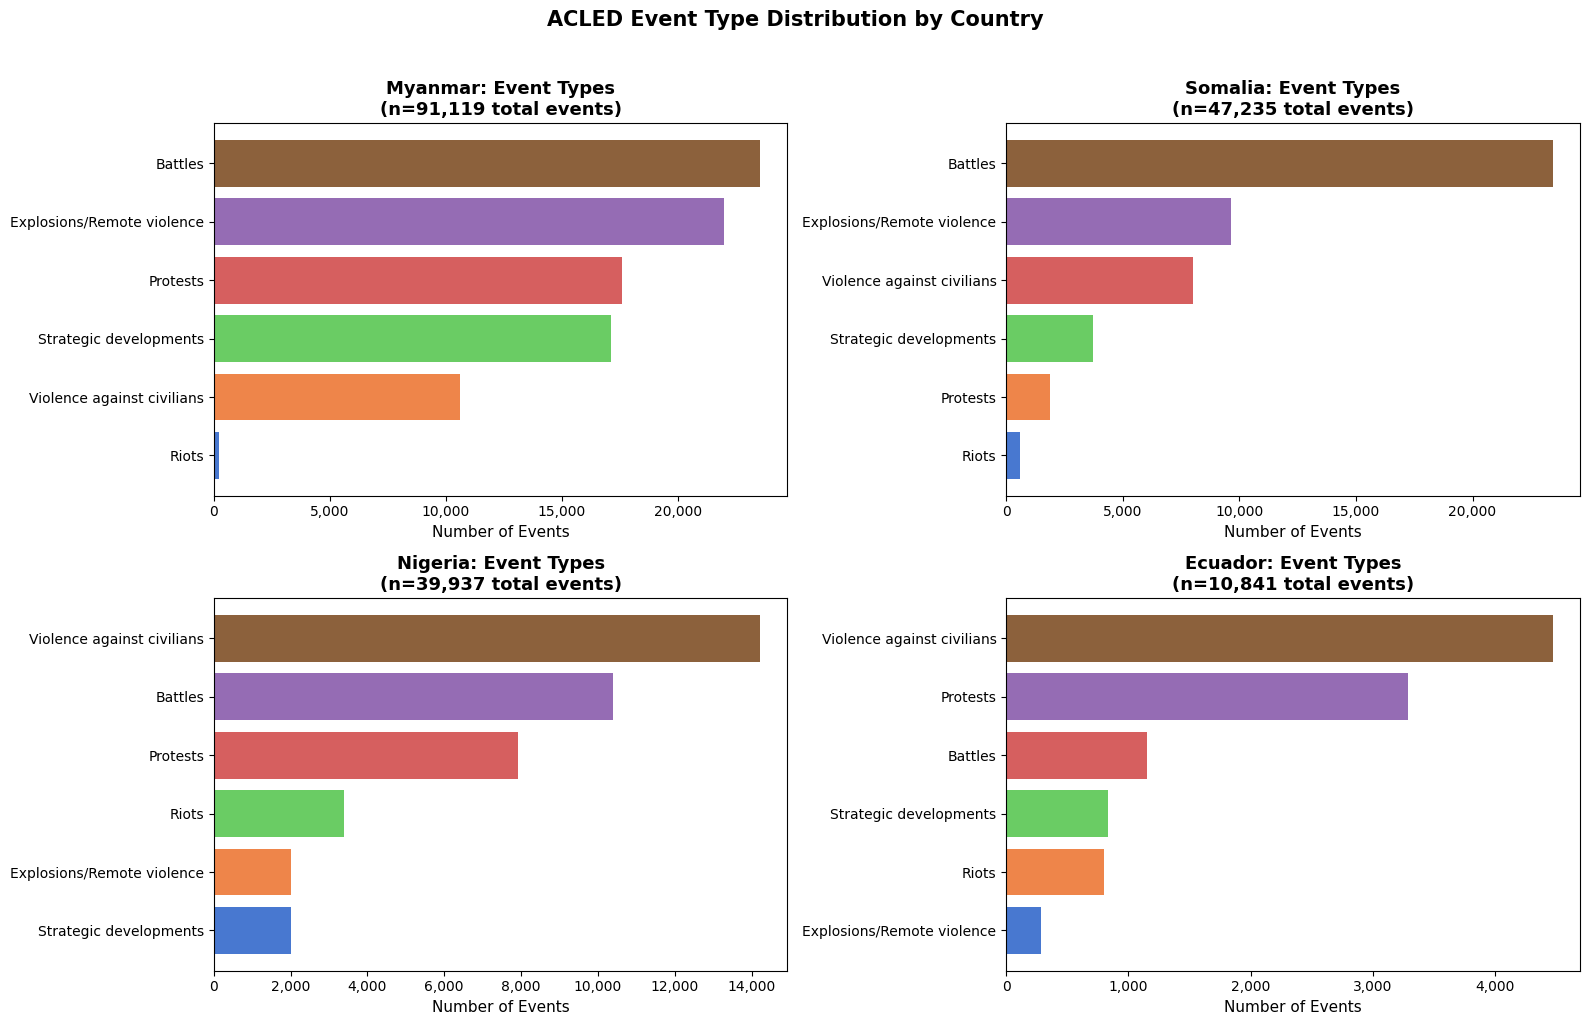

✅ Figure saved to reports/figures/


In [8]:
# ── CELL 5: Event Type Distribution — Core to Our HMM Method ──────────────────
# CONCEPT: The ratio of "Battles" to "Explosions/Remote violence" is our primary
# signal for territorial control. An actor controlling territory fights conventional
# battles. An actor WITHOUT territory uses bombs and ambushes (guerrilla tactics).
# This is exactly what the Hidden Markov Model will learn to detect.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))          # create a 2x2 grid of subplots (one per country)
axes = axes.flatten()                                       # flatten to a 1D list so we can loop through them easily

for idx, (country, df) in enumerate(acled.items()):        # loop through each country with its index number

    event_counts = (
        df["event_type"]                                   # select the event_type column
        .value_counts()                                    # count how many times each event type appears
        .sort_values(ascending=True)                       # sort smallest to largest for horizontal bar chart
    )

    axes[idx].barh(                                        # horizontal bar chart (easier to read long labels)
        event_counts.index,                                # y-axis: event type names
        event_counts.values,                               # x-axis: counts
        color=sns.color_palette("muted", len(event_counts))  # muted colour palette — professional look
    )
    axes[idx].set_title(                                   # chart title for this country
        f"{country}: Event Types\n(n={len(df):,} total events)",  # include total event count in title
        fontsize=13,                                       # font size for the title
        fontweight="bold"                                  # make title bold
    )
    axes[idx].set_xlabel("Number of Events", fontsize=11) # label the x-axis
    axes[idx].xaxis.set_major_formatter(                   # format x-axis numbers with comma separators
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}") # lambda = a small inline function; x = the tick value
    )

plt.suptitle(                                              # overall title for the entire figure
    "ACLED Event Type Distribution by Country",
    fontsize=15,
    fontweight="bold",
    y=1.02                                                 # y=1.02 places the title slightly above the plots
)
plt.tight_layout()                                         # automatically adjust spacing so labels don't overlap
plt.savefig(                                               # save the figure to disk for your report
    "../reports/figures/01_event_type_distribution.png",
    dpi=150,                                               # dots per inch — 150 is good for reports
    bbox_inches="tight"                                    # don't cut off labels at the edges
)
plt.show()                                                 # display the chart in the notebook
print("✅ Figure saved to reports/figures/")               # confirm save was successful


In [9]:
# ── CELL 6: Top Actors Per Country ─────────────────────────────────────────────
# CONCEPT: 'actor1' is the initiating/attacking side. The actors most frequently
# appearing in actor1 are the most ACTIVE groups — likely the ones whose territorial
# control we want to map. This tells us who our subjects of analysis are.

for country, df in acled.items():                          # loop through each country

    print(f"\n{'='*60}")                                   # visual separator between countries
    print(f"TOP 15 ACTORS (actor1) — {country}")          # header showing which country
    print(f"{'='*60}")

    top_actors = (
        df["actor1"]                                       # select the actor1 column
        .value_counts()                                    # count events per actor
        .head(15)                                          # keep only the top 15 most active actors
    )

    for actor, count in top_actors.items():                # loop through each actor and their event count
        pct = count / len(df) * 100                        # calculate what percentage of all events this actor represents
        bar = "█" * int(pct)                               # create a simple text bar chart using block characters
        print(f"  {actor[:45]:<45} {count:>6,} ({pct:>5.1f}%) {bar}")  # print formatted row


TOP 15 ACTORS (actor1) — Myanmar
  Military Forces of Myanmar (2021-)            33,667 ( 36.9%) ████████████████████████████████████
  Protesters (Myanmar)                          17,614 ( 19.3%) ███████████████████
  Unidentified Armed Group (Myanmar)             6,581 (  7.2%) ███████
  Military Forces of Myanmar (2016-2021)         3,617 (  4.0%) ███
  Military Forces of Myanmar (2011-2016)         2,164 (  2.4%) ██
  Civilians (Myanmar)                            1,854 (  2.0%) ██
  KIO/KIA: Kachin Independence Organization/Kac  1,560 (  1.7%) █
  Unidentified Anti-Coup Armed Group             1,325 (  1.5%) █
  KNU/KNLA: Karen National Union/Karen National  1,175 (  1.3%) █
  ULA/AA: United League of Arakan/Arakan Army    1,159 (  1.3%) █
  PSLF/TNLA: Palaung State Liberation Front/Ta'    743 (  0.8%) 
  Police Forces of Myanmar (2021-)                 674 (  0.7%) 
  People's Defense Force - Myaing                  538 (  0.6%) 
  MNTJP/MNDAA: Myanmar National Truth and Justi 

In [10]:
# ── CELL 7: Verify GPS Coverage and Precision ──────────────────────────────────
# CONCEPT: geo_precision tells us how accurate each event's location is.
# Level 1 = exact GPS point. Level 2 = nearby area. Level 3 = only know the
# admin district (centroid is used). For territorial control mapping, level 3
# events are less useful — we know WHERE but only roughly.

print("GEO PRECISION LEVELS ACROSS ALL COUNTRIES")
print("(1=Exact location, 2=Nearby, 3=Admin centroid only)")
print("=" * 60)

for country, df in acled.items():                          # loop through each country
    precision_counts = df["geo_precision"].value_counts()  # count how many events have each precision level
    total = len(df)                                        # total events for this country
    print(f"\n{country}:")                                 # print country name
    for level, count in sorted(precision_counts.items()): # loop through precision levels 1, 2, 3
        pct = count / total * 100                          # percentage at this precision level
        print(f"  Level {level}: {count:>7,} events ({pct:.1f}%)")  # formatted output

print("\n" + "=" * 60)
print("MISSING GPS COORDINATES:")                          # check for events with no location at all
for country, df in acled.items():
    missing = df["latitude"].isna().sum()                  # count rows where latitude is blank/null
    print(f"  {country}: {missing:,} events with no GPS")  # report missing count

GEO PRECISION LEVELS ACROSS ALL COUNTRIES
(1=Exact location, 2=Nearby, 3=Admin centroid only)

Myanmar:
  Level 1:  49,822 events (54.7%)
  Level 2:  40,516 events (44.5%)
  Level 3:     781 events (0.9%)

Somalia:
  Level 1:  38,344 events (81.2%)
  Level 2:   8,045 events (17.0%)
  Level 3:     846 events (1.8%)

Nigeria:
  Level 1:  25,451 events (63.7%)
  Level 2:  13,880 events (34.8%)
  Level 3:     606 events (1.5%)

Ecuador:
  Level 1:   9,908 events (91.4%)
  Level 2:     813 events (7.5%)
  Level 3:     120 events (1.1%)

MISSING GPS COORDINATES:
  Myanmar: 0 events with no GPS
  Somalia: 0 events with no GPS
  Nigeria: 0 events with no GPS
  Ecuador: 0 events with no GPS


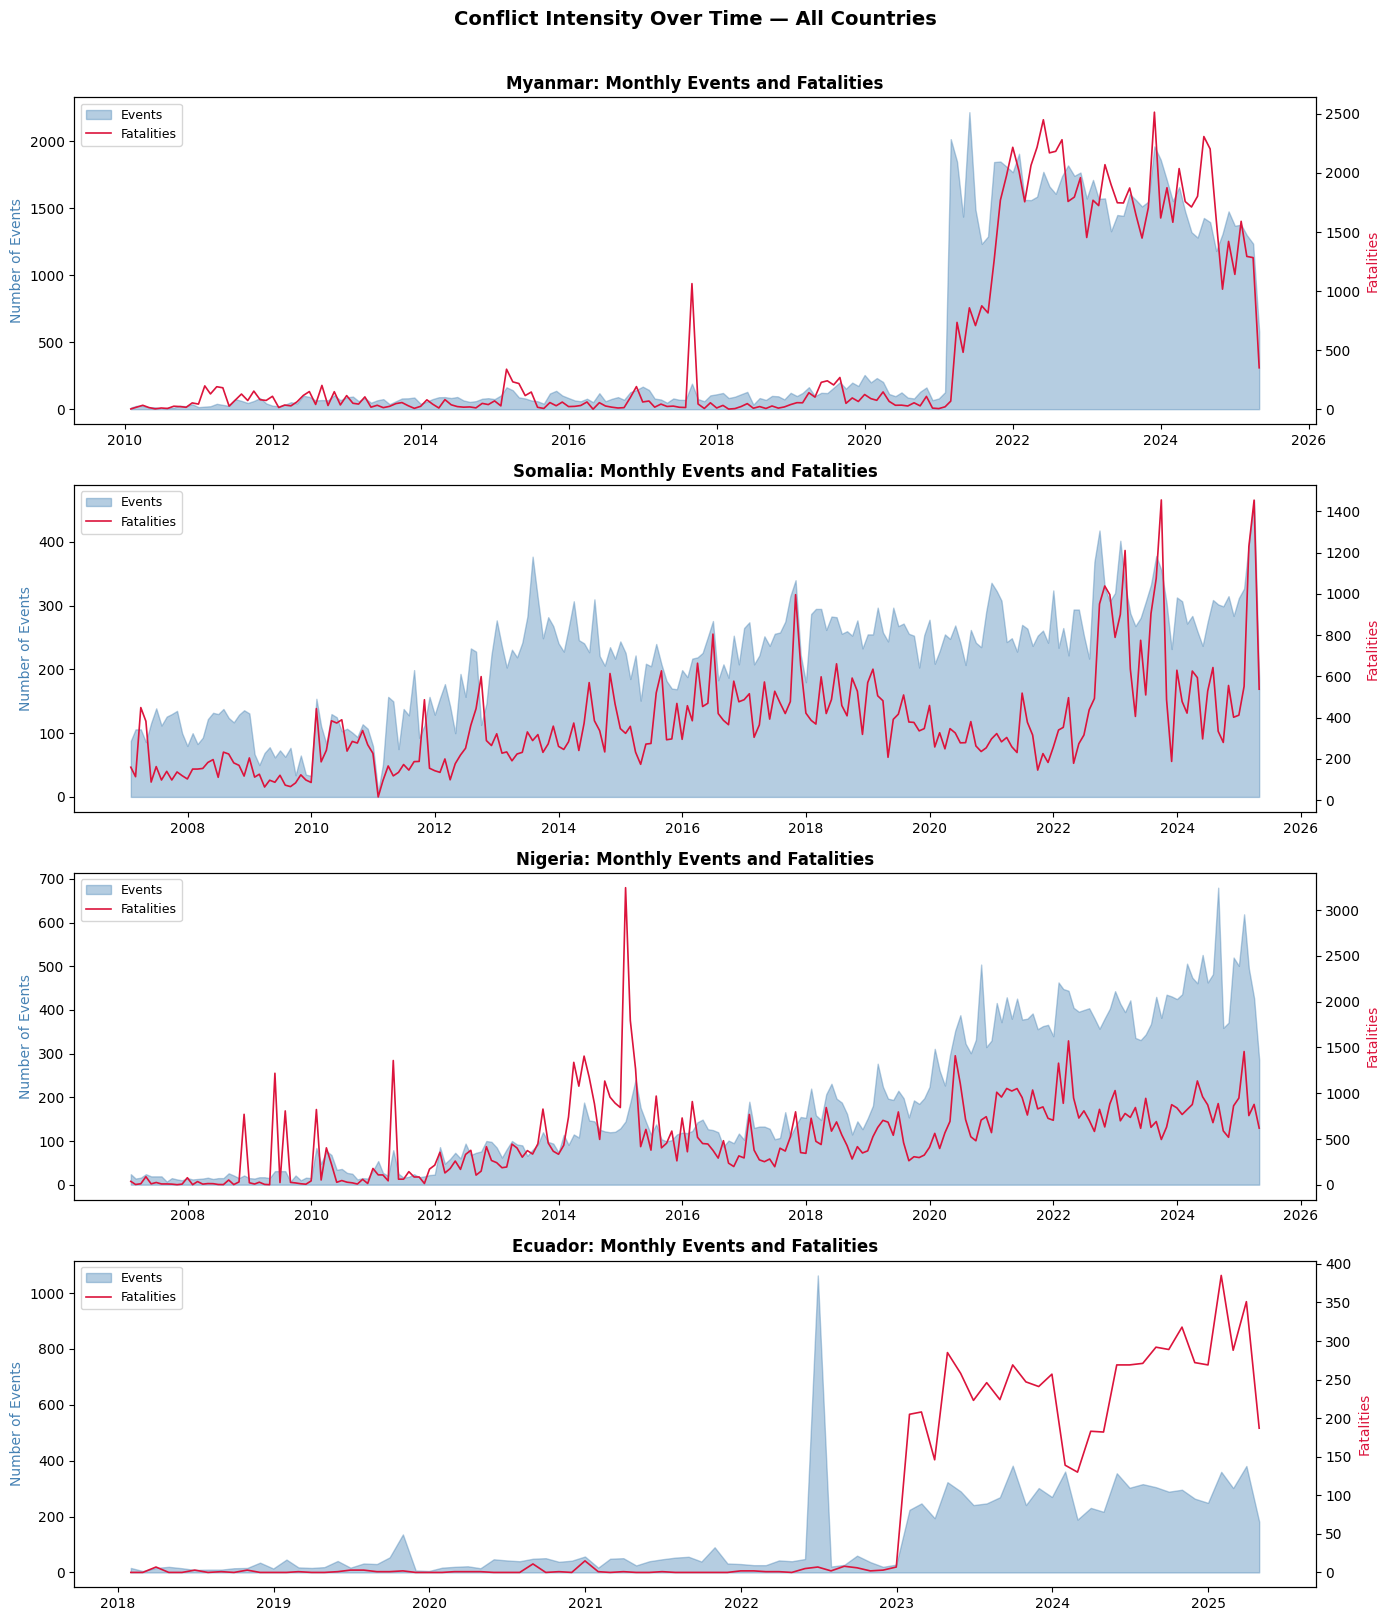

✅ Time series figure saved


In [ ]:
# ── CELL 8: Events Over Time — Does Our Data Make Sense? ──────────────────────
# CONCEPT: Before we model anything, we do a "sanity check" (= does this look
# right compared to what we know about history?). For Nigeria, we should see
# a spike around 2014-2015 (Boko Haram's peak). For Myanmar, a spike after
# the February 2021 coup. If we don't see these, something is wrong with the data.

fig, axes = plt.subplots(4, 1, figsize=(14, 16))           # four stacked time series plots, one per country

for idx, (country, df) in enumerate(acled.items()):        # loop through each country with its index

    df_indexed = df.set_index("event_date")                # make event_date the row index for resampling

    monthly_events = (
        df_indexed["fatalities"]                           # select fatalities as a Series
        .resample("ME")                                    # group by month-end
        .count()                                           # count = number of events per month (not sum)
        .reset_index()                                     # move date back to a regular column
        .rename(columns={"fatalities": "events"})          # rename count column to 'events' for clarity
    )

    monthly_fatalities = (
        df_indexed["fatalities"]                           # select fatalities as a Series again
        .resample("ME")                                    # group by month-end
        .sum()                                             # sum = total deaths per month
        .reset_index()                                     # move date back to a regular column
    )

    ax1 = axes[idx]                                        # left y-axis for event counts
    ax2 = ax1.twinx()                                      # right y-axis for fatalities — shares the x-axis

    ax1.fill_between(                                      # filled area chart for event counts
        monthly_events["event_date"],                      # x-axis: month dates
        monthly_events["events"],                          # y-axis: number of events that month
        alpha=0.4,                                         # semi-transparent so both series are visible
        color="steelblue",                                 # blue for events
        label="Events"                                     # legend label
    )

    ax2.plot(                                              # line chart for fatalities
        monthly_fatalities["event_date"],                  # x-axis: month dates
        monthly_fatalities["fatalities"],                  # y-axis: deaths per month
        color="crimson",                                   # red for deaths
        linewidth=1.2,                                     # thin line so it doesn't dominate
        label="Fatalities"                                 # legend label
    )

    ax1.set_title(f"{country}: Monthly Events and Fatalities", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Number of Events", color="steelblue", fontsize=10)   # left axis label in blue
    ax2.set_ylabel("Fatalities", color="crimson", fontsize=10)            # right axis label in red

    lines1, labels1 = ax1.get_legend_handles_labels()     # get event legend items from left axis
    lines2, labels2 = ax2.get_legend_handles_labels()     # get fatality legend items from right axis
    ax1.legend(lines1 + lines2, labels1 + labels2,        # merge both into one legend
               loc="upper left", fontsize=9)

plt.suptitle("Conflict Intensity Over Time — All Countries", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()                                         # prevent labels from overlapping each other
plt.savefig("../reports/figures/02_time_series_all_countries.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Time series figure saved")

In [12]:
# ── CELL 9: Load UCDP GED and Compare Structure to ACLED ──────────────────────
# CONCEPT: UCDP GED is our validation dataset. It codes events more conservatively
# than ACLED — it requires stronger evidence before recording an event. So UCDP
# will always have FEWER events than ACLED for the same country/period. The overlap
# (events that BOTH datasets record) is our most reliable ground truth.

ucdp_file = list(RAW_UCDP.glob("*.csv"))[0]               # find the UCDP CSV automatically (glob = search by pattern)
ucdp = pd.read_csv(ucdp_file, low_memory=False)            # load the global UCDP dataset (~150MB, takes a moment)
print(f"✅ UCDP loaded: {len(ucdp):,} events globally | {ucdp.shape[1]} columns")

# Filter UCDP to only our four countries (type_of_violence column: 1=state, 2=non-state, 3=one-sided)
our_countries = ["Myanmar", "Somalia", "Nigeria", "Ecuador"]       # our focus countries
ucdp_filtered = ucdp[ucdp["country"].isin(our_countries)].copy()  # keep only rows matching our countries
print(f"\nUCDP events in our 4 countries: {len(ucdp_filtered):,}")

# Count events per country in UCDP
print("\nUCDP events by country:")
print(ucdp_filtered["country"].value_counts())             # show event counts per country

# Show UCDP column names so we can compare to ACLED
print("\nUCDP COLUMNS:")
print(ucdp_filtered.dtypes)                                # print all column names and their types

✅ UCDP loaded: 385,918 events globally | 49 columns

UCDP events in our 4 countries: 15,011

UCDP events by country:
country
Nigeria    7418
Somalia    6868
Ecuador     725
Name: count, dtype: int64

UCDP COLUMNS:
id                     int64
relid                    str
year                   int64
active_year             bool
code_status              str
type_of_violence       int64
conflict_dset_id       int64
conflict_new_id        int64
conflict_name            str
dyad_dset_id           int64
dyad_new_id            int64
dyad_name                str
side_a_dset_id         int64
side_a_new_id          int64
side_a                   str
side_b_dset_id         int64
side_b_new_id          int64
side_b                   str
number_of_sources      int64
source_article           str
source_office            str
source_date              str
source_headline          str
source_original          str
where_prec             int64
where_coordinates        str
where_description        str
adm

In [15]:
# ── CELL 9b: Check Myanmar in UCDP — it may use a different country name ───────

# Search for any UCDP entry that mentions Burma or Myanmar
myanmar_check = ucdp[                                          # search the full global UCDP dataset
    ucdp["country"].str.contains("Myanmar|Burma", case=False, na=False)  # case=False = ignore capitalisation
]
print(f"UCDP Myanmar/Burma entries: {len(myanmar_check)}")    # print how many rows matched
print(myanmar_check["country"].value_counts())                # show exact country name UCDP uses

UCDP Myanmar/Burma entries: 8476
country
Myanmar (Burma)    8476
Name: count, dtype: int64


In [16]:
# ── CELL 9c: Fix UCDP country name and re-filter ──────────────────────────────

# UCDP uses "Myanmar (Burma)" not "Myanmar" — we must match their exact naming
our_countries_ucdp = {                         # dictionary mapping OUR names → UCDP's exact names
    "Myanmar": "Myanmar (Burma)",              # UCDP calls it this — includes the colonial name
    "Somalia": "Somalia",                      # matches exactly
    "Nigeria": "Nigeria",                      # matches exactly
    "Ecuador": "Ecuador",                      # matches exactly
}

ucdp_filtered = ucdp[                          # filter the global UCDP to only our countries
    ucdp["country"].isin(our_countries_ucdp.values())  # .values() = the UCDP-side names
].copy()                                       # .copy() prevents pandas from modifying the original

print("UCDP events by country (corrected):")
print(ucdp_filtered["country"].value_counts()) # confirm all four countries now appear

print(f"\nTotal UCDP events across our 4 countries: {len(ucdp_filtered):,}")

UCDP events by country (corrected):
country
Myanmar (Burma)    8476
Nigeria            7418
Somalia            6868
Ecuador             725
Name: count, dtype: int64

Total UCDP events across our 4 countries: 23,487


✅ Myanmar admin level 1: 15 regions
       NAME_1                                           geometry
0  Ayeyarwady  MULTIPOLYGON (((94.64847 16.2505, 94.64894 16....
1        Bago  MULTIPOLYGON (((96.90305 16.80917, 96.90361 16...
2        Chin  MULTIPOLYGON (((92.66836 21.30609, 92.66812 21...
3      Kachin  MULTIPOLYGON (((96.95166 23.71944, 96.94721 23...
4       Kayah  MULTIPOLYGON (((97.35664 18.59554, 97.35526 18...
5       Kayin  MULTIPOLYGON (((98.58312 16.06054, 98.58199 16...
6      Magway  MULTIPOLYGON (((95.79526 19.17637, 95.79276 19...
7    Mandalay  MULTIPOLYGON (((96.37776 19.47137, 96.37303 19...
8         Mon  MULTIPOLYGON (((97.78555 14.93001, 97.78528 14...
9   Naypyitaw  MULTIPOLYGON (((96.1436 19.7175, 96.13734 19.7...


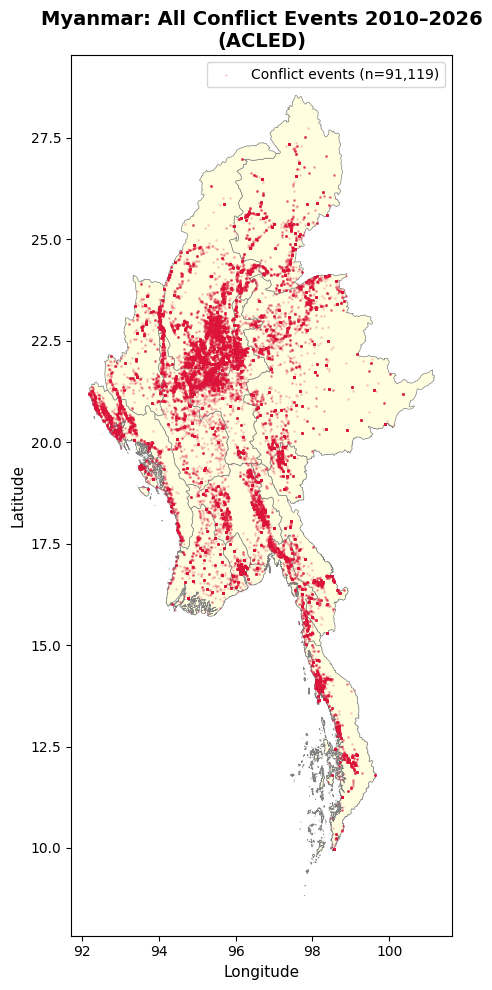

✅ Myanmar map saved


In [13]:
# ── CELL 10: Load GADM Boundaries and Plot a Quick Map ────────────────────────
# CONCEPT: GADM gives us the geographic canvas. Admin Level 0 = country border.
# Admin Level 1 = states/regions (e.g. "Shan State" in Myanmar).
# Admin Level 2 = districts. We'll overlay our conflict events on these boundaries.

# Load Myanmar boundaries as our first example (layer='ADM_ADM_1' = state level)
myanmar_adm1 = gpd.read_file(                              # read the GeoPackage file into a GeoDataFrame
    RAW_GADM / "gadm41_MMR.gpkg",                          # path to Myanmar GeoPackage
    layer="ADM_ADM_1"                                      # which layer to load: ADM_ADM_1 = state/region level
)
print(f"✅ Myanmar admin level 1: {len(myanmar_adm1)} regions")  # confirm how many regions loaded
print(myanmar_adm1[["NAME_1", "geometry"]].head(10))             # preview region names and their geometry type

# Quick map: admin boundaries + conflict events
fig, ax = plt.subplots(figsize=(10, 10))                   # create a single large square plot

myanmar_adm1.plot(                                         # draw the admin boundary polygons
    ax=ax,                                                 # draw on our existing axes
    color="lightyellow",                                   # fill colour for regions
    edgecolor="gray",                                      # border colour between regions
    linewidth=0.5                                          # thin borders
)

# Overlay conflict events as scatter points
myanmar_df = acled["Myanmar"].dropna(subset=["latitude", "longitude"])  # remove events with no GPS
ax.scatter(
    myanmar_df["longitude"],                               # x-axis = east-west position
    myanmar_df["latitude"],                                # y-axis = north-south position
    s=1,                                                   # s = dot size (very small so dots don't overlap)
    alpha=0.15,                                            # very transparent — density shows through overlapping dots
    color="crimson",                                       # red dots for conflict events
    label=f"Conflict events (n={len(myanmar_df):,})"      # legend entry with event count
)

ax.set_title("Myanmar: All Conflict Events 2010–2026\n(ACLED)", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=11)                    # label x-axis
ax.set_ylabel("Latitude", fontsize=11)                     # label y-axis
ax.legend(fontsize=10)                                     # show the legend
plt.tight_layout()
plt.savefig("../reports/figures/03_myanmar_conflict_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Myanmar map saved")

# Summary
KEY TIME SERIES FINDINGS — SANITY CHECK RESULTS
================================================

MYANMAR:
- Clear structural break at February 2021 (military coup) ✅
- Events increase ~40x from pre-coup baseline to post-coup sustained level
- Conflict remains extremely high through April 2025 — ongoing
- HMM ideal case: clean before/after for model validation

SOMALIA:
- 2010-2011 spike matches Al-Shabaab territorial peak + AMISOM offensive ✅
- Persistent conflict with high variance in fatalities (mass-casualty events)
- 2023-2025 new escalation — dataset is current and policy-relevant
- Long time series (2007-2025) = strongest temporal signal for HMM

NIGERIA:
- 2014-2015 Boko Haram peak clearly visible — events AND fatalities ✅
- 2015-2016 collapse matches military counter-offensive ✅
- Post-2017 shift: more events, lower fatalities = conflict type change
- Best validation case: known history allows ground-truth comparison

ECUADOR:
- Near-zero baseline until late 2022, then vertical spike ✅
- Matches historical record: criminal organisation collapse + gang war
- Rising fatalities 2022-2025 confirm escalating territorial violence
- Hardest methodological test: criminal vs. political territorial control

UCDP FINDING:
- UCDP uses "Myanmar (Burma)" — name mismatch corrected
- UCDP confirms 8,476 Myanmar events — dataset validates ✅
